<a href="https://colab.research.google.com/github/MK0514/research/blob/main/HammerHead_%EA%B3%B5%EB%A0%A5%ED%8A%B9%EC%84%B1_%EB%B6%84%EC%84%9D_%EB%B0%8F_%EC%88%98%EC%B9%98%ED%95%B4%EC%84%9D_%EB%B9%84%EA%B5%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

-----------------------------------------------------------------
기법 (Scheme)                      | 시간 (ms)  | L2 오차    | L_inf 오차 (최대진동)
-----------------------------------------------------------------
1차 풍상차분 (Upwind / AUSM Base)   |    38.0 |   0.1284 |   0.4812
Roe + TVD (고해상도 풍상차분)          |    49.7 |   0.1071 |   0.5700
JST (중앙차분 + 인공점성)              |    76.0 |   0.0891 |   0.5855
-----------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54413 (\N{HANGUL SYLLABLE PUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

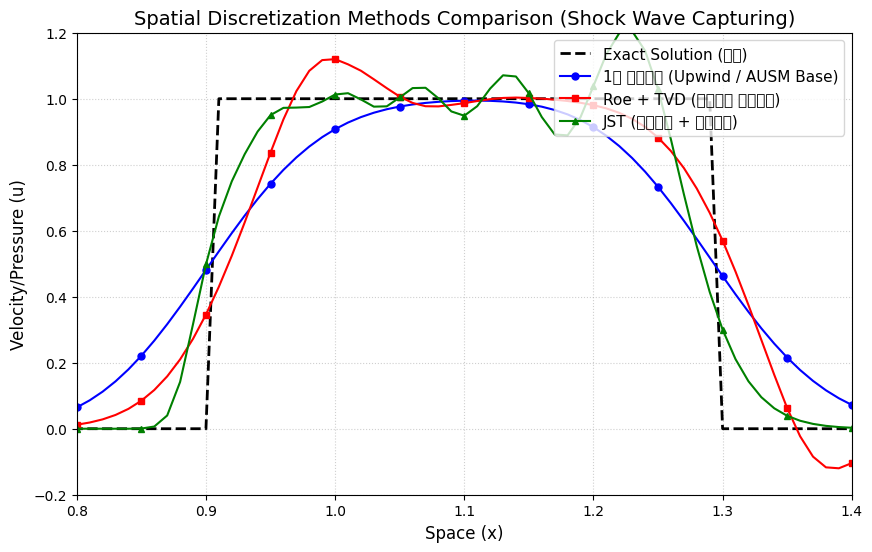

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# =====================================================================
# 1. 수치해석 기법 (공간 이산화 Flux 계산 함수들)
# =====================================================================

def flux_upwind(u, c):
    """
    기법 1: 1차 풍상 차분 (1st-Order Upwind)
    - AUSM+ 등 Flux Splitting의 가장 기본이 되는 기법.
    - 장점: 연산이 가장 빠르다.
    - 단점: 수치 점성(Numerical Diffusion)이 커서 충격파가 뭉개짐.
    """
    up = np.pad(u, 1, mode='wrap') # 주기적 경계조건
    i = np.arange(1, len(u) + 1)

    # c > 0 일 때 상류(Upwind)의 값을 가져옴
    F = 0.5 * c * (up[i] + up[i+1]) - 0.5 * abs(c) * (up[i+1] - up[i])
    return F

def flux_roe_tvd(u, c):
    """
    기법 2: Roe's FDS + MUSCL TVD (Minmod 리미터)
    - 고해상도(High-resolution) 2차 풍상 차분법.
    - 장점: 충격파를 진동 없이 가장 선명하고 정확하게 잡아냄.
    - 단점: 상태(State) 계산과 리미터 적용으로 연산량이 많음.
    """
    up = np.pad(u, 2, mode='wrap')
    N = len(u)
    i = np.arange(2, N + 2)

    # Left State (uL) 계산 + Minmod Limiter
    du_i = up[i] - up[i-1]
    du_im1 = up[i-1] - up[i-2]
    r_i = du_im1 / (du_i + 1e-10)
    phi_i = np.maximum(0.0, np.minimum(1.0, r_i)) # Minmod
    uL = up[i] + 0.5 * phi_i * du_i

    # Right State (uR) 계산 + Minmod Limiter
    du_ip1 = up[i+1] - up[i]
    du_ip2 = up[i+2] - up[i+1]
    r_ip1 = du_ip2 / (du_ip1 + 1e-10)
    phi_ip1 = np.maximum(0.0, np.minimum(1.0, r_ip1))
    uR = up[i+1] - 0.5 * phi_ip1 * du_ip1

    # Roe Flux 결합
    F = 0.5 * c * (uL + uR) - 0.5 * abs(c) * (uR - uL)
    return F

def flux_jst(u, c):
    """
    기법 3: JST 기법 (2차 중앙 차분 + 인공 점성)
    - Jameson-Schmidt-Turkel 고전적 기법.
    - 장점: 중앙 차분 기반이라 속도가 빠름.
    - 단점: 충격파 센서 튜닝이 까다롭고, 진동(Wiggle)이 발생함.
    """
    up = np.pad(u, 2, mode='wrap')
    N = len(u)
    i = np.arange(2, N + 2)

    # 1. 2차 중앙 차분 Flux
    F_cent = 0.5 * c * (up[i] + up[i+1])

    # 2. 충격파 센서 (압력 기울기 대신 u 기울기 사용)
    num = np.abs(up[i+1] - 2*up[i] + up[i-1])
    den = np.abs(up[i+1]) + 2*np.abs(up[i]) + np.abs(up[i-1]) + 1e-10
    nu_i = num / den

    num_ip1 = np.abs(up[i+2] - 2*up[i+1] + up[i])
    den_ip1 = np.abs(up[i+2]) + 2*np.abs(up[i+1]) + np.abs(up[i]) + 1e-10
    nu_ip1 = num_ip1 / den_ip1

    # 3. 인공 점성 계수 (2차 및 4차)
    k2 = 0.5
    k4 = 0.02
    eps2 = k2 * np.maximum(nu_i, nu_ip1)
    eps4 = np.maximum(0.0, k4 - eps2)

    # 4. Dissipation 항
    diff1 = up[i+1] - up[i]
    diff3 = up[i+2] - 3*up[i+1] + 3*up[i] - up[i-1]

    F_jst = F_cent - abs(c) * (eps2 * diff1 - eps4 * diff3)
    return F_jst

# =====================================================================
# 2. 시간 적분 엔진 (3단 Runge-Kutta, RK3)
# =====================================================================
def solve_rk3(u0, flux_func, c, dx, dt, steps):
    u = u0.copy()
    for _ in range(steps):
        # Stage 1
        F = flux_func(u, c)
        R = (F - np.roll(F, 1)) / dx
        u1 = u - dt * R

        # Stage 2
        F1 = flux_func(u1, c)
        R1 = (F1 - np.roll(F1, 1)) / dx
        u2 = 0.75 * u + 0.25 * u1 - 0.25 * dt * R1

        # Stage 3
        F2 = flux_func(u2, c)
        R2 = (F2 - np.roll(F2, 1)) / dx
        u = 1/3 * u + 2/3 * u2 - 2/3 * dt * R2
    return u

# =====================================================================
# 3. 시뮬레이션 설정 및 실행
# =====================================================================
N = 200                     # 격자 개수
x = np.linspace(0, 2, N, endpoint=False)
dx = 2.0 / N
c = 1.0                     # 파동 이동 속도
CFL = 0.5
dt = CFL * dx / c           # 시간 간격
t_end = 0.5                 # 최종 시뮬레이션 시간
steps = int(t_end / dt)     # 반복 스텝 수

# 초기 조건: 계단 함수 (충격파 모사)
u0 = np.where((x > 0.4) & (x < 0.8), 1.0, 0.0)
# 참값(Exact Solution): t_end 만큼 평행 이동한 계단 함수
u_exact = np.where((x > 0.4 + c*t_end) & (x < 0.8 + c*t_end), 1.0, 0.0)

# 해석 기법 딕셔너리
schemes = {
    "1차 풍상차분 (Upwind / AUSM Base)": flux_upwind,
    "Roe + TVD (고해상도 풍상차분)": flux_roe_tvd,
    "JST (중앙차분 + 인공점성)": flux_jst
}

results = {}

print("-" * 65)
print(f"{'기법 (Scheme)':<32} | {'시간 (ms)':<8} | {'L2 오차':<8} | {'L_inf 오차 (최대진동)':<15}")
print("-" * 65)

for name, func in schemes.items():
    # 실행 시간 측정 시작
    start_time = time.perf_counter()

    # 솔버 실행
    u_final = solve_rk3(u0, func, c, dx, dt, steps)

    # 실행 시간 측정 종료
    calc_time = (time.perf_counter() - start_time) * 1000 # 밀리초(ms)

    # 오차율 계산
    l2_error = np.sqrt(np.mean((u_final - u_exact)**2))
    linf_error = np.max(np.abs(u_final - u_exact))

    results[name] = u_final

    # 표 출력
    print(f"{name:<30} | {calc_time:>7.1f} | {l2_error:>8.4f} | {linf_error:>8.4f}")

print("-" * 65)

# =====================================================================
# 4. 결과 시각화
# =====================================================================
plt.figure(figsize=(10, 6))
plt.plot(x, u_exact, 'k--', lw=2, label='Exact Solution (참값)')

colors = ['blue', 'red', 'green']
markers = ['o', 's', '^']

for (name, u_final), col, mk in zip(results.items(), colors, markers):
    plt.plot(x, u_final, color=col, marker=mk, markevery=5, markersize=5, lw=1.5, label=name)

plt.title("Spatial Discretization Methods Comparison (Shock Wave Capturing)", fontsize=14)
plt.xlabel("Space (x)", fontsize=12)
plt.ylabel("Velocity/Pressure (u)", fontsize=12)
plt.xlim(0.8, 1.4)  # 충격파가 위치한 부분만 확대해서 표시
plt.ylim(-0.2, 1.2)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')
plt.show()

--------------------------------------------------------------------------------
기법 (Scheme)               | 스텝 수     | 계산 시간(ms)  | L2 오차       
--------------------------------------------------------------------------------
1. 명시적 오일러 (작은 dt)        |      108 |         5.94 |   0.00004685
2. 명시적 RK4 (작은 dt)        |      108 |        30.05 |   0.00002748
3. ADI 암시적 기법 (큰 dt)      |       10 |        40.38 |   0.00002681
--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

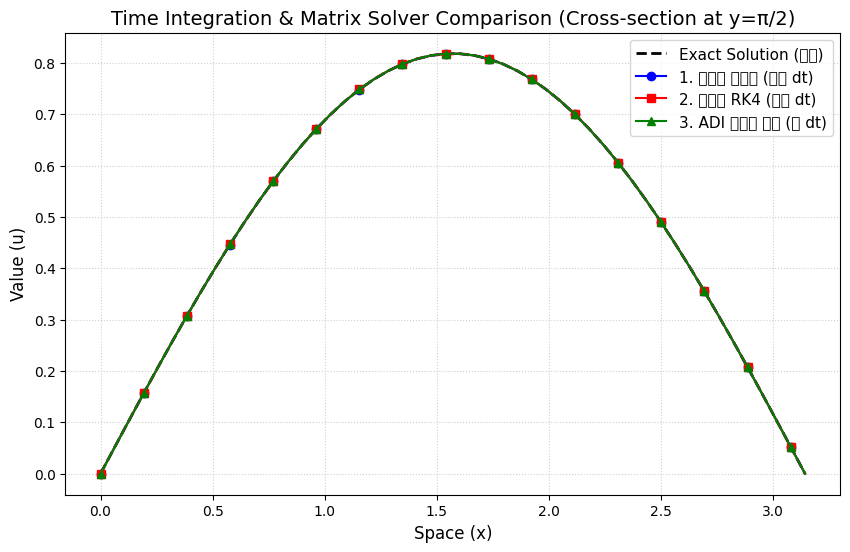

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
import time

# =====================================================================
# 1. 2D 확산 방정식 (시간 적분) 솔버들
# =====================================================================

def solve_explicit_euler(u0, alpha, dx, dy, dt, steps):
    """
    기법 1: 명시적 오일러 (Explicit Euler)
    - 가장 단순하지만, 안정성 한계(CFL)를 넘으면 바로 폭발함.
    """
    u = u0.copy()
    for _ in range(steps):
        # 2차 중앙차분으로 공간 2계 미분(Laplacian) 계산
        laplacian = (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1])/dx**2 + \
                    (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2])/dy**2
        u[1:-1, 1:-1] += dt * alpha * laplacian
    return u

def solve_rk4(u0, alpha, dx, dy, dt, steps):
    """
    기법 2: 명시적 4단 룽게-쿠타 (RK4)
    - 시간 정확도가 매우 높음 (4차). 그러나 여전히 명시적이라 dt 제약이 심함.
    """
    u = u0.copy()

    def rhs(curr_u):
        res = np.zeros_like(curr_u)
        res[1:-1, 1:-1] = alpha * (
            (curr_u[2:, 1:-1] - 2*curr_u[1:-1, 1:-1] + curr_u[:-2, 1:-1])/dx**2 +
            (curr_u[1:-1, 2:] - 2*curr_u[1:-1, 1:-1] + curr_u[1:-1, :-2])/dy**2
        )
        return res

    for _ in range(steps):
        k1 = dt * rhs(u)
        k2 = dt * rhs(u + 0.5*k1)
        k3 = dt * rhs(u + 0.5*k2)
        k4 = dt * rhs(u + k3)
        u += (k1 + 2*k2 + 2*k3 + k4) / 6.0
    return u

def solve_adi(u0, alpha, dx, dy, dt, steps):
    """
    기법 3: ADI (교대 방향 암시적 기법) + TDMA (Thomas Algorithm)
    - x방향, y방향을 번갈아 가며 암시적으로 계산.
    - dt를 크게 잡아도 절대 폭발하지 않는 무조건적 안정성(Unconditionally stable).
    """
    u = u0.copy()
    nx, ny = u.shape
    rx = alpha * dt / (2 * dx**2)
    ry = alpha * dt / (2 * dy**2)

    # TDMA를 위한 삼중대각행렬 (Tridiagonal Matrix) 세팅 [Upper, Main, Lower]
    ab_x = np.zeros((3, nx-2))
    ab_x[0, 1:] = -rx        # Upper diagonal
    ab_x[1, :]  = 1 + 2*rx   # Main diagonal
    ab_x[2, :-1] = -rx       # Lower diagonal

    ab_y = np.zeros((3, ny-2))
    ab_y[0, 1:] = -ry
    ab_y[1, :]  = 1 + 2*ry
    ab_y[2, :-1] = -ry

    for _ in range(steps):
        # Step 1: x방향 암시적(Implicit), y방향 명시적(Explicit)
        u_half = np.zeros_like(u)
        for j in range(1, ny-1):
            d = ry * u[1:-1, j-1] + (1 - 2*ry) * u[1:-1, j] + ry * u[1:-1, j+1]
            # scipy의 solve_banded가 C언어 기반의 초고속 TDMA 알고리즘을 수행함
            u_half[1:-1, j] = solve_banded((1, 1), ab_x, d)

        # Step 2: x방향 명시적(Explicit), y방향 암시적(Implicit)
        for i in range(1, nx-1):
            d = rx * u_half[i-1, 1:-1] + (1 - 2*rx) * u_half[i, 1:-1] + rx * u_half[i+1, 1:-1]
            u[i, 1:-1] = solve_banded((1, 1), ab_y, d)

    return u

# =====================================================================
# 2. 시뮬레이션 설정 및 실행
# =====================================================================
N = 50                                  # 격자 수 (50 x 50)
L = np.pi
x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)
dx = L / (N - 1)
dy = L / (N - 1)

alpha = 0.1                             # 확산(점성) 계수
t_end = 1.0                             # 최종 시뮬레이션 시간

# 초기 조건 (가운데가 볼록한 2D 사인파)
u0 = np.sin(X) * np.sin(Y)

# 참값 (시간이 t_end 만큼 흘렀을 때의 수학적 정답)
u_exact = np.exp(-2 * alpha * t_end) * np.sin(X) * np.sin(Y)

# --- 명시적 기법(Euler, RK4)의 안정성 한계 계산 ---
# dt <= dx^2 / (4 * alpha)
dt_limit = (dx**2) / (4 * alpha)
dt_explicit = dt_limit * 0.9            # 한계치보다 약간 작게 (안전하게)
steps_explicit = int(t_end / dt_explicit)
dt_explicit = t_end / steps_explicit    # 시간 딱 맞추기 보정

# --- 암시적 기법(ADI)의 혜택 (큰 시간 간격) ---
# ADI는 안정성 한계가 없으므로 dt를 명시적 방법의 10배로 크게 설정!
dt_adi = dt_explicit * 10.0
steps_adi = int(t_end / dt_adi)
dt_adi = t_end / steps_adi

schemes = {
    "1. 명시적 오일러 (작은 dt)": (solve_explicit_euler, dt_explicit, steps_explicit),
    "2. 명시적 RK4 (작은 dt)": (solve_rk4, dt_explicit, steps_explicit),
    "3. ADI 암시적 기법 (큰 dt)": (solve_adi, dt_adi, steps_adi)
}

results = {}

print("-" * 80)
print(f"{'기법 (Scheme)':<25} | {'스텝 수':<8} | {'계산 시간(ms)':<10} | {'L2 오차':<12}")
print("-" * 80)

for name, (func, dt_used, steps_used) in schemes.items():
    start_time = time.perf_counter()

    # 솔버 실행
    u_final = func(u0, alpha, dx, dy, dt_used, steps_used)

    calc_time = (time.perf_counter() - start_time) * 1000
    l2_error = np.sqrt(np.mean((u_final - u_exact)**2))

    results[name] = u_final

    print(f"{name:<25} | {steps_used:>8d} | {calc_time:>12.2f} | {l2_error:>12.8f}")

print("-" * 80)

# =====================================================================
# 3. 결과 시각화 (보고서용 중심 단면 그래프)
# =====================================================================
mid = N // 2 # 2D 배열의 중앙(y = pi/2) 단면 자르기

plt.figure(figsize=(10, 6))
plt.plot(x, u_exact[mid, :], 'k--', lw=2, label='Exact Solution (참값)')

colors = ['blue', 'red', 'green']
markers = ['o', 's', '^']

for (name, u_final), col, mk in zip(results.items(), colors, markers):
    plt.plot(x, u_final[mid, :], color=col, marker=mk, markevery=3, markersize=6, lw=1.5, label=name)

plt.title("Time Integration & Matrix Solver Comparison (Cross-section at y=π/2)", fontsize=14)
plt.xlabel("Space (x)", fontsize=12)
plt.ylabel("Value (u)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

--------------------------------------------------------------------------------
기법 (Scheme)               | 스텝 수     | 계산 시간(ms)  | L2 오차       
--------------------------------------------------------------------------------


/tmp/ipykernel_21042/627940346.py:137: RuntimeWarning: overflow encountered in square
  l2_error = np.sqrt(np.mean((u_final - u_exact)**2))


1. 명시적 오일러 (작은 dt)        |      160 |       269.23 |          inf


/tmp/ipykernel_21042/627940346.py:33: RuntimeWarning: overflow encountered in divide
  (curr_u[2:, 1:-1] - 2*curr_u[1:-1, 1:-1] + curr_u[:-2, 1:-1])/dx**2 +
/tmp/ipykernel_21042/627940346.py:34: RuntimeWarning: overflow encountered in divide
  (curr_u[1:-1, 2:] - 2*curr_u[1:-1, 1:-1] + curr_u[1:-1, :-2])/dy**2
/tmp/ipykernel_21042/627940346.py:33: RuntimeWarning: overflow encountered in add
  (curr_u[2:, 1:-1] - 2*curr_u[1:-1, 1:-1] + curr_u[:-2, 1:-1])/dx**2 +
/tmp/ipykernel_21042/627940346.py:40: RuntimeWarning: invalid value encountered in add
  k2 = dt * rhs(u + 0.5*k1)
/tmp/ipykernel_21042/627940346.py:33: RuntimeWarning: invalid value encountered in subtract
  (curr_u[2:, 1:-1] - 2*curr_u[1:-1, 1:-1] + curr_u[:-2, 1:-1])/dx**2 +
/tmp/ipykernel_21042/627940346.py:33: RuntimeWarning: invalid value encountered in add
  (curr_u[2:, 1:-1] - 2*curr_u[1:-1, 1:-1] + curr_u[:-2, 1:-1])/dx**2 +
/tmp/ipykernel_21042/627940346.py:34: RuntimeWarning: invalid value encountered in subtract
  (c

2. 명시적 RK4 (작은 dt)        |      160 |       782.56 |          nan
3. ADI 암시적 기법 (큰 dt)      |       16 |       300.10 |   0.00000143
--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

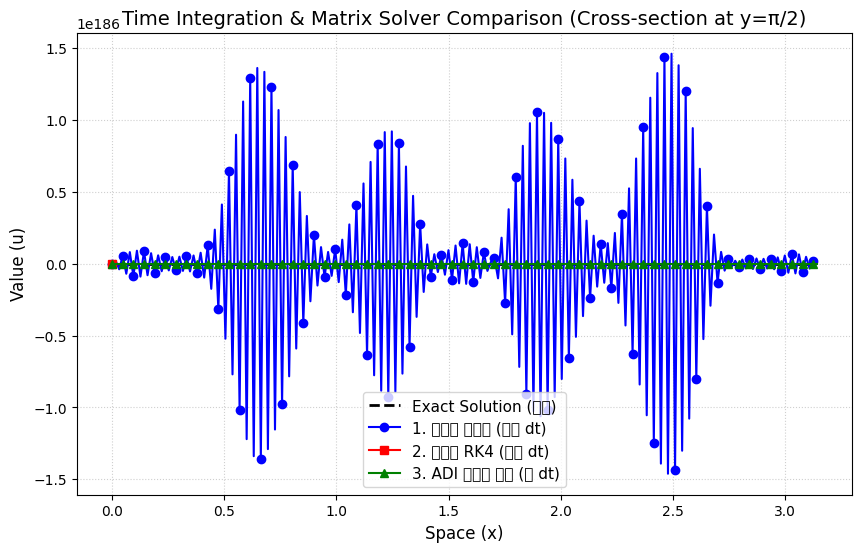

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
import time

# =====================================================================
# 1. 2D 확산 방정식 (시간 적분) 솔버들
# =====================================================================

def solve_explicit_euler(u0, alpha, dx, dy, dt, steps):
    """
    기법 1: 명시적 오일러 (Explicit Euler)
    - 가장 단순하지만, 안정성 한계(CFL)를 넘으면 바로 폭발함.
    """
    u = u0.copy()
    for _ in range(steps):
        # 2차 중앙차분으로 공간 2계 미분(Laplacian) 계산
        laplacian = (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1])/dx**2 + \
                    (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2])/dy**2
        u[1:-1, 1:-1] += dt * alpha * laplacian
    return u

def solve_rk4(u0, alpha, dx, dy, dt, steps):
    """
    기법 2: 명시적 4단 룽게-쿠타 (RK4)
    - 시간 정확도가 매우 높음 (4차). 그러나 여전히 명시적이라 dt 제약이 심함.
    """
    u = u0.copy()

    def rhs(curr_u):
        res = np.zeros_like(curr_u)
        res[1:-1, 1:-1] = alpha * (
            (curr_u[2:, 1:-1] - 2*curr_u[1:-1, 1:-1] + curr_u[:-2, 1:-1])/dx**2 +
            (curr_u[1:-1, 2:] - 2*curr_u[1:-1, 1:-1] + curr_u[1:-1, :-2])/dy**2
        )
        return res

    for _ in range(steps):
        k1 = dt * rhs(u)
        k2 = dt * rhs(u + 0.5*k1)
        k3 = dt * rhs(u + 0.5*k2)
        k4 = dt * rhs(u + k3)
        u += (k1 + 2*k2 + 2*k3 + k4) / 6.0
    return u

def solve_adi(u0, alpha, dx, dy, dt, steps):
    """
    기법 3: ADI (교대 방향 암시적 기법) + TDMA (Thomas Algorithm)
    - x방향, y방향을 번갈아 가며 암시적으로 계산.
    - dt를 크게 잡아도 절대 폭발하지 않는 무조건적 안정성(Unconditionally stable).
    """
    u = u0.copy()
    nx, ny = u.shape
    rx = alpha * dt / (2 * dx**2)
    ry = alpha * dt / (2 * dy**2)

    # TDMA를 위한 삼중대각행렬 (Tridiagonal Matrix) 세팅 [Upper, Main, Lower]
    ab_x = np.zeros((3, nx-2))
    ab_x[0, 1:] = -rx        # Upper diagonal
    ab_x[1, :]  = 1 + 2*rx   # Main diagonal
    ab_x[2, :-1] = -rx       # Lower diagonal

    ab_y = np.zeros((3, ny-2))
    ab_y[0, 1:] = -ry
    ab_y[1, :]  = 1 + 2*ry
    ab_y[2, :-1] = -ry

    for _ in range(steps):
        # Step 1: x방향 암시적(Implicit), y방향 명시적(Explicit)
        u_half = np.zeros_like(u)
        for j in range(1, ny-1):
            d = ry * u[1:-1, j-1] + (1 - 2*ry) * u[1:-1, j] + ry * u[1:-1, j+1]
            # scipy의 solve_banded가 C언어 기반의 초고속 TDMA 알고리즘을 수행함
            u_half[1:-1, j] = solve_banded((1, 1), ab_x, d)

        # Step 2: x방향 명시적(Explicit), y방향 암시적(Implicit)
        for i in range(1, nx-1):
            d = rx * u_half[i-1, 1:-1] + (1 - 2*rx) * u_half[i, 1:-1] + rx * u_half[i+1, 1:-1]
            u[i, 1:-1] = solve_banded((1, 1), ab_y, d)

    return u

# =====================================================================
# 2. 시뮬레이션 설정 및 실행
# =====================================================================
N = 200                            # 격자 수 (50 x 50)
L = np.pi
x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)
dx = L / (N - 1)
dy = L / (N - 1)

alpha = 0.1                             # 확산(점성) 계수
t_end = 1.0                             # 최종 시뮬레이션 시간

# 초기 조건 (가운데가 볼록한 2D 사인파)
u0 = np.sin(X) * np.sin(Y)

# 참값 (시간이 t_end 만큼 흘렀을 때의 수학적 정답)
u_exact = np.exp(-2 * alpha * t_end) * np.sin(X) * np.sin(Y)

# --- 명시적 기법(Euler, RK4)의 안정성 한계 계산 ---
# dt <= dx^2 / (4 * alpha)
dt_limit = (dx**2) / (4 * alpha)

#이부분 고침
dt_explicit = dt_limit * 10.0         # 한계치보다 약간 작게 (안전하게)
steps_explicit = int(t_end / dt_explicit)
dt_explicit = t_end / steps_explicit    # 시간 딱 맞추기 보정

# --- 암시적 기법(ADI)의 혜택 (큰 시간 간격) ---
# ADI는 안정성 한계가 없으므로 dt를 명시적 방법의 10배로 크게 설정!
dt_adi = dt_explicit * 10.0
steps_adi = int(t_end / dt_adi)
dt_adi = t_end / steps_adi

schemes = {
    "1. 명시적 오일러 (작은 dt)": (solve_explicit_euler, dt_explicit, steps_explicit),
    "2. 명시적 RK4 (작은 dt)": (solve_rk4, dt_explicit, steps_explicit),
    "3. ADI 암시적 기법 (큰 dt)": (solve_adi, dt_adi, steps_adi)
}

results = {}

print("-" * 80)
print(f"{'기법 (Scheme)':<25} | {'스텝 수':<8} | {'계산 시간(ms)':<10} | {'L2 오차':<12}")
print("-" * 80)

for name, (func, dt_used, steps_used) in schemes.items():
    start_time = time.perf_counter()

    # 솔버 실행
    u_final = func(u0, alpha, dx, dy, dt_used, steps_used)

    calc_time = (time.perf_counter() - start_time) * 1000
    l2_error = np.sqrt(np.mean((u_final - u_exact)**2))

    results[name] = u_final

    print(f"{name:<25} | {steps_used:>8d} | {calc_time:>12.2f} | {l2_error:>12.8f}")

print("-" * 80)

# =====================================================================
# 3. 결과 시각화 (보고서용 중심 단면 그래프)
# =====================================================================
mid = N // 2 # 2D 배열의 중앙(y = pi/2) 단면 자르기

plt.figure(figsize=(10, 6))
plt.plot(x, u_exact[mid, :], 'k--', lw=2, label='Exact Solution (참값)')

colors = ['blue', 'red', 'green']
markers = ['o', 's', '^']

for (name, u_final), col, mk in zip(results.items(), colors, markers):
    plt.plot(x, u_final[mid, :], color=col, marker=mk, markevery=3, markersize=6, lw=1.5, label=name)

plt.title("Time Integration & Matrix Solver Comparison (Cross-section at y=π/2)", fontsize=14)
plt.xlabel("Space (x)", fontsize=12)
plt.ylabel("Value (u)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

--------------------------------------------------------------------------------
기법 (Scheme)               | 스텝 수     | 계산 시간(ms)  | L2 오차       
--------------------------------------------------------------------------------
1. 명시적 오일러 (작은 dt)        |    11212 |     45229.07 |   0.00000046
2. 명시적 RK4 (작은 dt)        |    11212 |    378312.84 |   0.00000027
3. ADI 암시적 기법 (큰 dt)      |     1121 |     72915.23 |   0.00000027
--------------------------------------------------------------------------------


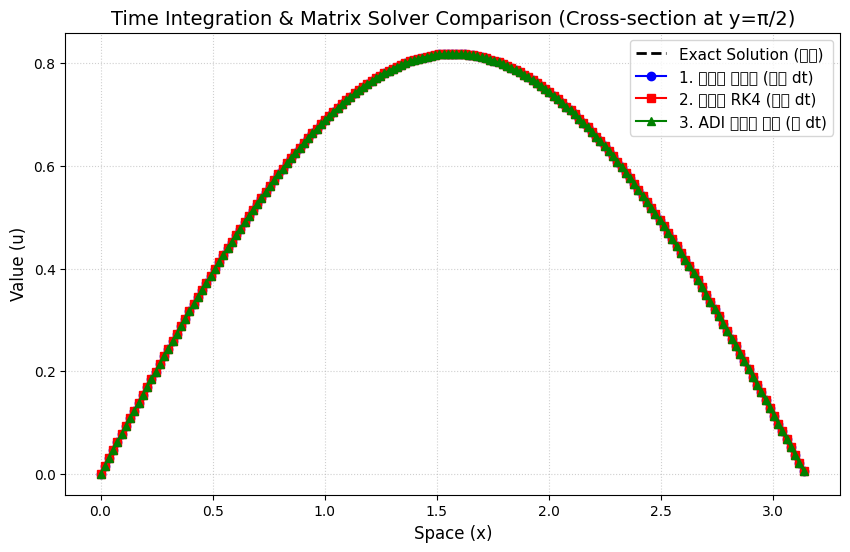

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
import time

# =====================================================================
# 1. 2D 확산 방정식 (시간 적분) 솔버들
# =====================================================================

def solve_explicit_euler(u0, alpha, dx, dy, dt, steps):
    """
    기법 1: 명시적 오일러 (Explicit Euler)
    - 가장 단순하지만, 안정성 한계(CFL)를 넘으면 바로 폭발함.
    """
    u = u0.copy()
    for _ in range(steps):
        # 2차 중앙차분으로 공간 2계 미분(Laplacian) 계산
        laplacian = (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1])/dx**2 + \
                    (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2])/dy**2
        u[1:-1, 1:-1] += dt * alpha * laplacian
    return u

def solve_rk4(u0, alpha, dx, dy, dt, steps):
    """
    기법 2: 명시적 4단 룽게-쿠타 (RK4)
    - 시간 정확도가 매우 높음 (4차). 그러나 여전히 명시적이라 dt 제약이 심함.
    """
    u = u0.copy()

    def rhs(curr_u):
        res = np.zeros_like(curr_u)
        res[1:-1, 1:-1] = alpha * (
            (curr_u[2:, 1:-1] - 2*curr_u[1:-1, 1:-1] + curr_u[:-2, 1:-1])/dx**2 +
            (curr_u[1:-1, 2:] - 2*curr_u[1:-1, 1:-1] + curr_u[1:-1, :-2])/dy**2
        )
        return res

    for _ in range(steps):
        k1 = dt * rhs(u)
        k2 = dt * rhs(u + 0.5*k1)
        k3 = dt * rhs(u + 0.5*k2)
        k4 = dt * rhs(u + k3)
        u += (k1 + 2*k2 + 2*k3 + k4) / 6.0
    return u

def solve_adi(u0, alpha, dx, dy, dt, steps):
    """
    기법 3: ADI (교대 방향 암시적 기법) + TDMA (Thomas Algorithm)
    - x방향, y방향을 번갈아 가며 암시적으로 계산.
    - dt를 크게 잡아도 절대 폭발하지 않는 무조건적 안정성(Unconditionally stable).
    """
    u = u0.copy()
    nx, ny = u.shape
    rx = alpha * dt / (2 * dx**2)
    ry = alpha * dt / (2 * dy**2)

    # TDMA를 위한 삼중대각행렬 (Tridiagonal Matrix) 세팅 [Upper, Main, Lower]
    ab_x = np.zeros((3, nx-2))
    ab_x[0, 1:] = -rx        # Upper diagonal
    ab_x[1, :]  = 1 + 2*rx   # Main diagonal
    ab_x[2, :-1] = -rx       # Lower diagonal

    ab_y = np.zeros((3, ny-2))
    ab_y[0, 1:] = -ry
    ab_y[1, :]  = 1 + 2*ry
    ab_y[2, :-1] = -ry

    for _ in range(steps):
        # Step 1: x방향 암시적(Implicit), y방향 명시적(Explicit)
        u_half = np.zeros_like(u)
        for j in range(1, ny-1):
            d = ry * u[1:-1, j-1] + (1 - 2*ry) * u[1:-1, j] + ry * u[1:-1, j+1]
            # scipy의 solve_banded가 C언어 기반의 초고속 TDMA 알고리즘을 수행함
            u_half[1:-1, j] = solve_banded((1, 1), ab_x, d)

        # Step 2: x방향 명시적(Explicit), y방향 암시적(Implicit)
        for i in range(1, nx-1):
            d = rx * u_half[i-1, 1:-1] + (1 - 2*rx) * u_half[i, 1:-1] + rx * u_half[i+1, 1:-1]
            u[i, 1:-1] = solve_banded((1, 1), ab_y, d)

    return u

# =====================================================================
# 2. 시뮬레이션 설정 및 실행
# =====================================================================
#그리드 키움
N = 500                            # 격자 수 (50 x 50)
L = np.pi
x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)
dx = L / (N - 1)
dy = L / (N - 1)

alpha = 0.1                             # 확산(점성) 계수
t_end = 1.0                             # 최종 시뮬레이션 시간

# 초기 조건 (가운데가 볼록한 2D 사인파)
u0 = np.sin(X) * np.sin(Y)

# 참값 (시간이 t_end 만큼 흘렀을 때의 수학적 정답)
u_exact = np.exp(-2 * alpha * t_end) * np.sin(X) * np.sin(Y)

# --- 명시적 기법(Euler, RK4)의 안정성 한계 계산 ---
# dt <= dx^2 / (4 * alpha)
dt_limit = (dx**2) / (4 * alpha)

#이부분 고침
dt_explicit = dt_limit * 0.9       # 한계치보다 약간 작게 (안전하게)
steps_explicit = int(t_end / dt_explicit)
dt_explicit = t_end / steps_explicit    # 시간 딱 맞추기 보정

# --- 암시적 기법(ADI)의 혜택 (큰 시간 간격) ---
# ADI는 안정성 한계가 없으므로 dt를 명시적 방법의 10배로 크게 설정!
dt_adi = dt_explicit * 10.0
steps_adi = int(t_end / dt_adi)
dt_adi = t_end / steps_adi

schemes = {
    "1. 명시적 오일러 (작은 dt)": (solve_explicit_euler, dt_explicit, steps_explicit),
    "2. 명시적 RK4 (작은 dt)": (solve_rk4, dt_explicit, steps_explicit),
    "3. ADI 암시적 기법 (큰 dt)": (solve_adi, dt_adi, steps_adi)
}

results = {}

print("-" * 80)
print(f"{'기법 (Scheme)':<25} | {'스텝 수':<8} | {'계산 시간(ms)':<10} | {'L2 오차':<12}")
print("-" * 80)

for name, (func, dt_used, steps_used) in schemes.items():
    start_time = time.perf_counter()

    # 솔버 실행
    u_final = func(u0, alpha, dx, dy, dt_used, steps_used)

    calc_time = (time.perf_counter() - start_time) * 1000
    l2_error = np.sqrt(np.mean((u_final - u_exact)**2))

    results[name] = u_final

    print(f"{name:<25} | {steps_used:>8d} | {calc_time:>12.2f} | {l2_error:>12.8f}")

print("-" * 80)

# =====================================================================
# 3. 결과 시각화 (보고서용 중심 단면 그래프)
# =====================================================================
mid = N // 2 # 2D 배열의 중앙(y = pi/2) 단면 자르기

plt.figure(figsize=(10, 6))
plt.plot(x, u_exact[mid, :], 'k--', lw=2, label='Exact Solution (참값)')

colors = ['blue', 'red', 'green']
markers = ['o', 's', '^']

for (name, u_final), col, mk in zip(results.items(), colors, markers):
    plt.plot(x, u_final[mid, :], color=col, marker=mk, markevery=3, markersize=6, lw=1.5, label=name)

plt.title("Time Integration & Matrix Solver Comparison (Cross-section at y=π/2)", fontsize=14)
plt.xlabel("Space (x)", fontsize=12)
plt.ylabel("Value (u)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

--------------------------------------------------------------------------------
기법 (Scheme)               | 스텝 수     | 계산 시간(ms)  | L2 오차       
--------------------------------------------------------------------------------
1. 명시적 오일러 (작은 dt)        |     1783 |       881.49 |   0.00000288
2. 명시적 RK4 (작은 dt)        |     1783 |      4357.14 |   0.00000169
3. ADI 암시적 기법 (큰 dt)      |      178 |      4245.60 |   0.00000169
--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

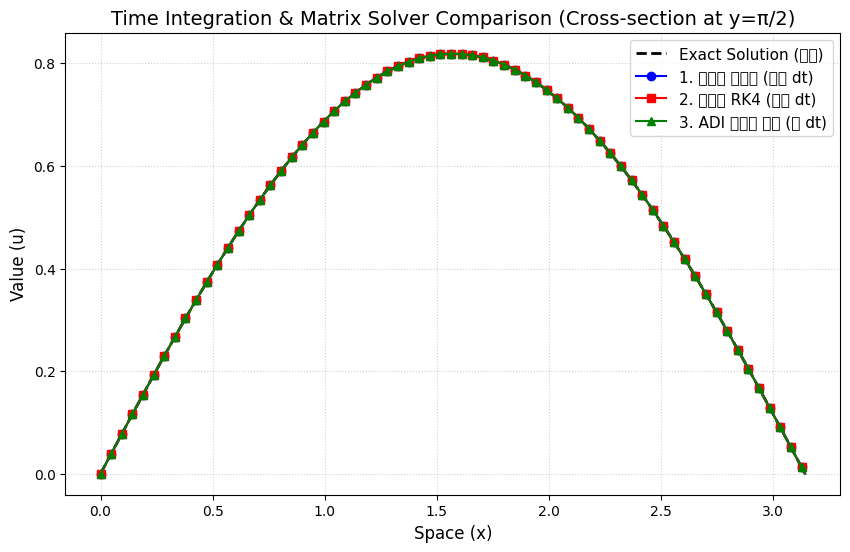

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
import time

# =====================================================================
# 1. 2D 확산 방정식 (시간 적분) 솔버들
# =====================================================================

def solve_explicit_euler(u0, alpha, dx, dy, dt, steps):
    """
    기법 1: 명시적 오일러 (Explicit Euler)
    - 가장 단순하지만, 안정성 한계(CFL)를 넘으면 바로 폭발함.
    """
    u = u0.copy()
    for _ in range(steps):
        # 2차 중앙차분으로 공간 2계 미분(Laplacian) 계산
        laplacian = (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1])/dx**2 + \
                    (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2])/dy**2
        u[1:-1, 1:-1] += dt * alpha * laplacian
    return u

def solve_rk4(u0, alpha, dx, dy, dt, steps):
    """
    기법 2: 명시적 4단 룽게-쿠타 (RK4)
    - 시간 정확도가 매우 높음 (4차). 그러나 여전히 명시적이라 dt 제약이 심함.
    """
    u = u0.copy()

    def rhs(curr_u):
        res = np.zeros_like(curr_u)
        res[1:-1, 1:-1] = alpha * (
            (curr_u[2:, 1:-1] - 2*curr_u[1:-1, 1:-1] + curr_u[:-2, 1:-1])/dx**2 +
            (curr_u[1:-1, 2:] - 2*curr_u[1:-1, 1:-1] + curr_u[1:-1, :-2])/dy**2
        )
        return res

    for _ in range(steps):
        k1 = dt * rhs(u)
        k2 = dt * rhs(u + 0.5*k1)
        k3 = dt * rhs(u + 0.5*k2)
        k4 = dt * rhs(u + k3)
        u += (k1 + 2*k2 + 2*k3 + k4) / 6.0
    return u

def solve_adi(u0, alpha, dx, dy, dt, steps):
    """
    기법 3: ADI (교대 방향 암시적 기법) + TDMA (Thomas Algorithm)
    - x방향, y방향을 번갈아 가며 암시적으로 계산.
    - dt를 크게 잡아도 절대 폭발하지 않는 무조건적 안정성(Unconditionally stable).
    """
    u = u0.copy()
    nx, ny = u.shape
    rx = alpha * dt / (2 * dx**2)
    ry = alpha * dt / (2 * dy**2)

    # TDMA를 위한 삼중대각행렬 (Tridiagonal Matrix) 세팅 [Upper, Main, Lower]
    ab_x = np.zeros((3, nx-2))
    ab_x[0, 1:] = -rx        # Upper diagonal
    ab_x[1, :]  = 1 + 2*rx   # Main diagonal
    ab_x[2, :-1] = -rx       # Lower diagonal

    ab_y = np.zeros((3, ny-2))
    ab_y[0, 1:] = -ry
    ab_y[1, :]  = 1 + 2*ry
    ab_y[2, :-1] = -ry

    for _ in range(steps):
        # Step 1: x방향 암시적(Implicit), y방향 명시적(Explicit)
        u_half = np.zeros_like(u)
        for j in range(1, ny-1):
            d = ry * u[1:-1, j-1] + (1 - 2*ry) * u[1:-1, j] + ry * u[1:-1, j+1]
            # scipy의 solve_banded가 C언어 기반의 초고속 TDMA 알고리즘을 수행함
            u_half[1:-1, j] = solve_banded((1, 1), ab_x, d)

        # Step 2: x방향 명시적(Explicit), y방향 암시적(Implicit)
        for i in range(1, nx-1):
            d = rx * u_half[i-1, 1:-1] + (1 - 2*rx) * u_half[i, 1:-1] + rx * u_half[i+1, 1:-1]
            u[i, 1:-1] = solve_banded((1, 1), ab_y, d)

    return u

# =====================================================================
# 2. 시뮬레이션 설정 및 실행
# =====================================================================
N = 200                            # 격자 수 (50 x 50)
L = np.pi
x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)
dx = L / (N - 1)
dy = L / (N - 1)

alpha = 0.1                             # 확산(점성) 계수
t_end = 1.0                             # 최종 시뮬레이션 시간

# 초기 조건 (가운데가 볼록한 2D 사인파)
u0 = np.sin(X) * np.sin(Y)

# 참값 (시간이 t_end 만큼 흘렀을 때의 수학적 정답)
u_exact = np.exp(-2 * alpha * t_end) * np.sin(X) * np.sin(Y)

# --- 명시적 기법(Euler, RK4)의 안정성 한계 계산 ---
# dt <= dx^2 / (4 * alpha)
dt_limit = (dx**2) / (4 * alpha)

#이부분 고침
dt_explicit = dt_limit *0.9       # 한계치보다 약간 작게 (안전하게)
steps_explicit = int(t_end / dt_explicit)
dt_explicit = t_end / steps_explicit    # 시간 딱 맞추기 보정

# --- 암시적 기법(ADI)의 혜택 (큰 시간 간격) ---
# ADI는 안정성 한계가 없으므로 dt를 명시적 방법의 10배로 크게 설정!
dt_adi = dt_explicit * 10.0
steps_adi = int(t_end / dt_adi)
dt_adi = t_end / steps_adi

schemes = {
    "1. 명시적 오일러 (작은 dt)": (solve_explicit_euler, dt_explicit, steps_explicit),
    "2. 명시적 RK4 (작은 dt)": (solve_rk4, dt_explicit, steps_explicit),
    "3. ADI 암시적 기법 (큰 dt)": (solve_adi, dt_adi, steps_adi)
}

results = {}

print("-" * 80)
print(f"{'기법 (Scheme)':<25} | {'스텝 수':<8} | {'계산 시간(ms)':<10} | {'L2 오차':<12}")
print("-" * 80)

for name, (func, dt_used, steps_used) in schemes.items():
    start_time = time.perf_counter()

    # 솔버 실행
    u_final = func(u0, alpha, dx, dy, dt_used, steps_used)

    calc_time = (time.perf_counter() - start_time) * 1000
    l2_error = np.sqrt(np.mean((u_final - u_exact)**2))

    results[name] = u_final

    print(f"{name:<25} | {steps_used:>8d} | {calc_time:>12.2f} | {l2_error:>12.8f}")

print("-" * 80)

# =====================================================================
# 3. 결과 시각화 (보고서용 중심 단면 그래프)
# =====================================================================
mid = N // 2 # 2D 배열의 중앙(y = pi/2) 단면 자르기

plt.figure(figsize=(10, 6))
plt.plot(x, u_exact[mid, :], 'k--', lw=2, label='Exact Solution (참값)')

colors = ['blue', 'red', 'green']
markers = ['o', 's', '^']

for (name, u_final), col, mk in zip(results.items(), colors, markers):
    plt.plot(x, u_final[mid, :], color=col, marker=mk, markevery=3, markersize=6, lw=1.5, label=name)

plt.title("Time Integration & Matrix Solver Comparison (Cross-section at y=π/2)", fontsize=14)
plt.xlabel("Space (x)", fontsize=12)
plt.ylabel("Value (u)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

-----------------------------------------------------------------
Scheme (기법)          | Steps (스텝)   | Time(ms)   | L2 Error    
-----------------------------------------------------------------
1. Explicit Euler    |          441 |      57.38 |   0.00001158
-----------------------------------------------------------------


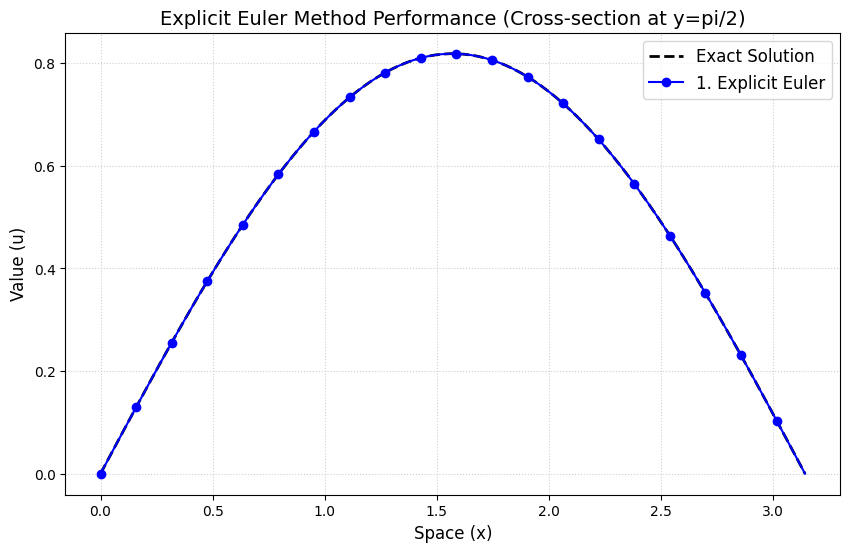

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import time

# =====================================================================
# 1. 명시적 오일러 솔버 단독 정의
# =====================================================================
def solve_explicit_euler(u0, alpha, dx, dy, dt, steps):
    """
    기법 1: 명시적 오일러 (Explicit Euler)
    - 가장 기초적인 시간 적분 기법.
    - dt 한계치를 엄격하게 지켜야만 발산(폭발)하지 않음.
    """
    u = u0.copy()
    for _ in range(steps):
        # 2차 중앙차분으로 공간 미분(Laplacian) 계산
        laplacian = (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1])/dx**2 + \
                    (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2])/dy**2

        # 다음 시간(t + dt)의 값 업데이트
        u[1:-1, 1:-1] += dt * alpha * laplacian
    return u

# =====================================================================
# 2. 시뮬레이션 설정
# =====================================================================
N = 100                                 # 격자 수 (100 x 100)
L = np.pi
x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)
dx = L / (N - 1)
dy = L / (N - 1)

alpha = 0.1                             # 점성(확산) 계수
t_end = 1.0                             # 최종 시뮬레이션 시간

# 초기 조건 (볼록한 2D 사인파)
u0 = np.sin(X) * np.sin(Y)

# 참값 (Exact Solution)
u_exact = np.exp(-2 * alpha * t_end) * np.sin(X) * np.sin(Y)

# --- 명시적 기법의 생명줄: 안정성 한계(CFL) 계산 ---
dt_limit = (dx**2) / (4 * alpha)
dt_explicit = dt_limit * 0.9            # 한계치보다 10% 안전하게 설정
steps_explicit = int(t_end / dt_explicit)
dt_explicit = t_end / steps_explicit    # 시간 오차 보정

# =====================================================================
# 3. 실행 및 결과 출력
# =====================================================================
print("-" * 65)
print(f"{'Scheme (기법)':<20} | {'Steps (스텝)':<12} | {'Time(ms)':<10} | {'L2 Error':<12}")
print("-" * 65)

# 실행 시간 측정
start_time = time.perf_counter()
u_euler = solve_explicit_euler(u0, alpha, dx, dy, dt_explicit, steps_explicit)
calc_time = (time.perf_counter() - start_time) * 1000

# L2 오차 계산
l2_error = np.sqrt(np.mean((u_euler - u_exact)**2))

print(f"{'1. Explicit Euler':<20} | {steps_explicit:>12d} | {calc_time:>10.2f} | {l2_error:>12.8f}")
print("-" * 65)

# =====================================================================
# 4. 단독 그래프 시각화
# =====================================================================
mid = N // 2 # 정중앙 단면 자르기

plt.figure(figsize=(10, 6))

# 참값 그리기 (검은색 점선)
plt.plot(x, u_exact[mid, :], 'k--', lw=2, label='Exact Solution')

# 명시적 오일러 결과 그리기 (파란색 실선)
plt.plot(x, u_euler[mid, :], color='blue', marker='o', markevery=5, markersize=6, lw=1.5, label='1. Explicit Euler')

plt.title("Explicit Euler Method Performance (Cross-section at y=pi/2)", fontsize=14)
plt.xlabel("Space (x)", fontsize=12)
plt.ylabel("Value (u)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)
plt.show()

---------------------------------------------------------------------------
Method (격자 기법)            | Time (계산 시간 ms)      | Orthogonality Error (오차)
---------------------------------------------------------------------------
1. Algebraic Grid         |             9.574 ms |            15.65 deg
2. Elliptic PDE Grid      |            54.697 ms |            15.65 deg
3. Hyperbolic Marching    |            41.514 ms |             0.15 deg
---------------------------------------------------------------------------


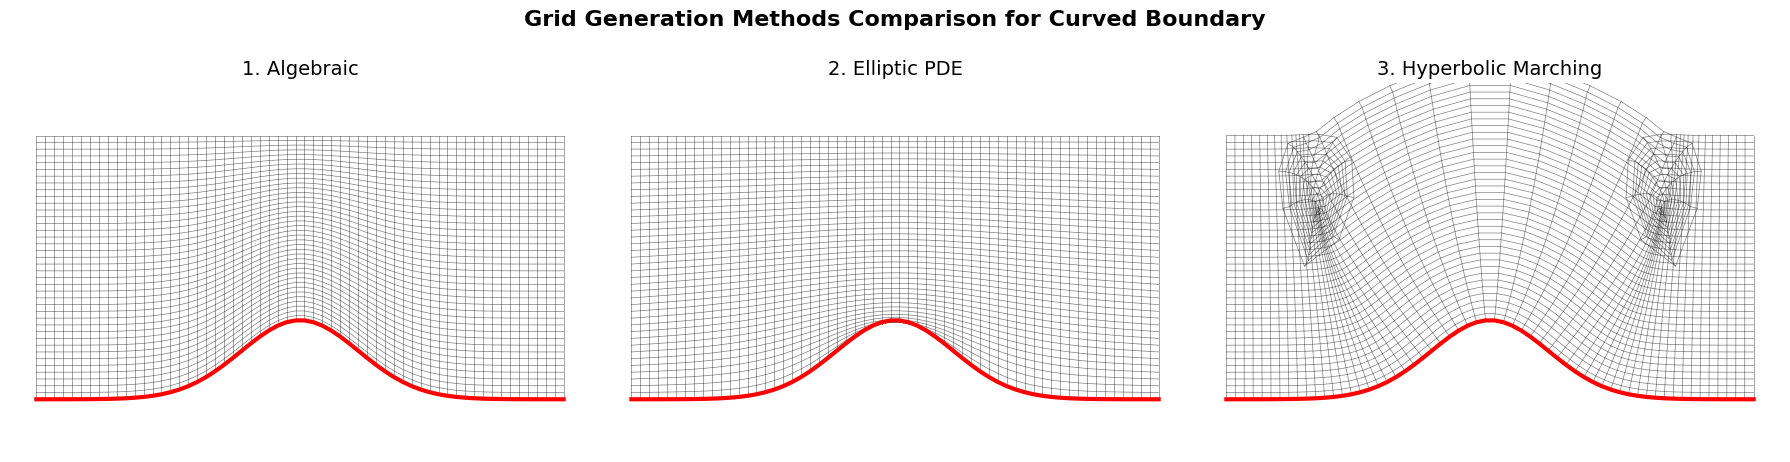

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import time

# =====================================================================
# 1. 기하 형상 정의 (볼록한 곡면이 있는 바닥)
# =====================================================================
Nx, Ny = 60, 40  # x방향, y방향 격자 수
L, H = 2.0, 1.0  # 도메인 가로 길이, 세로 높이

# 바닥 형상: 가운데가 볼록 솟아오른 형상 (해머헤드 곡면 모사)
x_base = np.linspace(0, L, Nx)
y_base = 0.3 * np.exp(-10 * (x_base - 1.0)**2)  # Gaussian bump

# =====================================================================
# 2. 격자 생성 기법들 (Grid Generation Methods)
# =====================================================================

def generate_algebraic():
    """
    1. 대수적 격자 (Algebraic Grid - Transfinite Interpolation)
    바닥 곡면과 천장(직선) 사이를 단순히 선형 보간하여 연결.
    """
    X = np.zeros((Ny, Nx))
    Y = np.zeros((Ny, Nx))

    for i in range(Nx):
        for j in range(Ny):
            eta = j / (Ny - 1)
            X[j, i] = x_base[i]
            # y는 바닥 곡면에서 천장 H까지 선형 비례
            Y[j, i] = y_base[i] + eta * (H - y_base[i])

    return X, Y

def generate_elliptic(X_init, Y_init, iterations=300):
    """
    2. 타원형 격자 (Elliptic PDE Grid)
    대수적 격자를 초기값으로 받아, 라플라스 평활화(Laplace smoothing) 수행.
    내부 격자가 주변 격자의 평균값이 되도록 반복 계산.
    """
    X = X_init.copy()
    Y = Y_init.copy()

    # 테두리(경계)는 고정하고 내부만 평활화
    for _ in range(iterations):
        X[1:-1, 1:-1] = 0.25 * (X[1:-1, 2:] + X[1:-1, :-2] + X[2:, 1:-1] + X[:-2, 1:-1])
        Y[1:-1, 1:-1] = 0.25 * (Y[1:-1, 2:] + Y[1:-1, :-2] + Y[2:, 1:-1] + Y[:-2, 1:-1])

    return X, Y

def generate_hyperbolic():
    """
    3. 쌍곡선 격자 모사 (Hyperbolic / Normal Marching)
    바닥(곡면)에서부터 윗방향으로 법선(Normal) 벡터를 따라 한 층씩 쌓아 올림.
    직교성(Orthogonality)이 가장 우수함.
    """
    X = np.zeros((Ny, Nx))
    Y = np.zeros((Ny, Nx))

    X[0, :] = x_base
    Y[0, :] = y_base

    dy_step = H / (Ny - 1)

    for j in range(1, Ny):
        for i in range(1, Nx - 1):
            # 이전 층의 표면 접선 벡터 계산
            tx = X[j-1, i+1] - X[j-1, i-1]
            ty = Y[j-1, i+1] - Y[j-1, i-1]
            length = np.sqrt(tx**2 + ty**2)

            # 수직인 법선(Normal) 벡터
            nx, ny = -ty / length, tx / length

            X[j, i] = X[j-1, i] + dy_step * nx
            Y[j, i] = Y[j-1, i] + dy_step * ny

        # 양 끝 경계조건 처리 (수직으로 올림)
        X[j, 0] = X[j-1, 0]; Y[j, 0] = Y[j-1, 0] + dy_step
        X[j, -1] = X[j-1, -1]; Y[j, -1] = Y[j-1, -1] + dy_step

        # 교차(Overlapping) 방지를 위한 약간의 내부 평활화
        if j < Ny - 1:
            X[j, 1:-1] = 0.25 * X[j, :-2] + 0.5 * X[j, 1:-1] + 0.25 * X[j, 2:]

    return X, Y

# =====================================================================
# 3. 직교성 평가 함수 (Orthogonality Error)
# =====================================================================
def calc_orthogonality_error(X, Y):
    """
    벽면(j=0)에서 격자가 얼마나 직각(90도)으로 뻗어 나가는지 측정.
    90도에서 빗나간 평균 각도(도 단위) 반환.
    """
    errors = []
    for i in range(1, Nx-1):
        # 벽면 접선 벡터
        tx = X[0, i+1] - X[0, i-1]
        ty = Y[0, i+1] - Y[0, i-1]
        # 벽면에서 나아가는 첫 번째 격자선 벡터
        vx = X[1, i] - X[0, i]
        vy = Y[1, i] - Y[0, i]

        dot_product = tx*vx + ty*vy
        mag_t = np.sqrt(tx**2 + ty**2)
        mag_v = np.sqrt(vx**2 + vy**2)

        # 두 벡터 사이의 각도 계산
        cos_theta = dot_product / (mag_t * mag_v)
        angle_rad = np.arccos(np.clip(cos_theta, -1.0, 1.0))
        angle_deg = np.degrees(angle_rad)

        # 90도와의 차이가 오차
        error = abs(90.0 - angle_deg)
        errors.append(error)

    return np.mean(errors)

# =====================================================================
# 4. 시뮬레이션 실행 및 결과 표 출력
# =====================================================================
results = {}

print("-" * 75)
print(f"{'Method (격자 기법)':<25} | {'Time (계산 시간 ms)':<20} | {'Orthogonality Error (오차)':<20}")
print("-" * 75)

# 1. 대수적 격자 (Algebraic)
start = time.perf_counter()
X_alg, Y_alg = generate_algebraic()
time_alg = (time.perf_counter() - start) * 1000
err_alg = calc_orthogonality_error(X_alg, Y_alg)
results['1. Algebraic'] = (X_alg, Y_alg)
print(f"{'1. Algebraic Grid':<25} | {time_alg:>17.3f} ms | {err_alg:>16.2f} deg")

# 2. 타원형 격자 (Elliptic PDE)
start = time.perf_counter()
X_ell, Y_ell = generate_elliptic(X_alg, Y_alg)
time_ell = (time.perf_counter() - start) * 1000
err_ell = calc_orthogonality_error(X_ell, Y_ell)
results['2. Elliptic PDE'] = (X_ell, Y_ell)
print(f"{'2. Elliptic PDE Grid':<25} | {time_ell:>17.3f} ms | {err_ell:>16.2f} deg")

# 3. 쌍곡선 격자 (Hyperbolic)
start = time.perf_counter()
X_hyp, Y_hyp = generate_hyperbolic()
time_hyp = (time.perf_counter() - start) * 1000
err_hyp = calc_orthogonality_error(X_hyp, Y_hyp)
results['3. Hyperbolic Marching'] = (X_hyp, Y_hyp)
print(f"{'3. Hyperbolic Marching':<25} | {time_hyp:>17.3f} ms | {err_hyp:>16.2f} deg")
print("-" * 75)

# =====================================================================
# 5. 시각화 (그래프 출력)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Grid Generation Methods Comparison for Curved Boundary", fontsize=16, fontweight='bold')

for ax, (name, (X, Y)) in zip(axes, results.items()):
    # 가로선(eta)과 세로선(xi) 그리기
    for i in range(Nx):
        ax.plot(X[:, i], Y[:, i], color='black', lw=0.5, alpha=0.5)
    for j in range(Ny):
        ax.plot(X[j, :], Y[j, :], color='black', lw=0.5, alpha=0.5)

    ax.plot(x_base, y_base, 'r-', lw=3, label="Curved Wall (Boat-tail)")
    ax.set_title(name, fontsize=14)
    ax.set_aspect('equal')
    ax.set_ylim(-0.2, 1.2)
    ax.axis('off')

plt.tight_layout()
plt.show()

--------------------------------------------------
Method                              | Time (ms) 
--------------------------------------------------
1. Uniform Algebraic                |    4.332 ms
2. Exponential Stretched (beta=3.5) |   15.484 ms
--------------------------------------------------


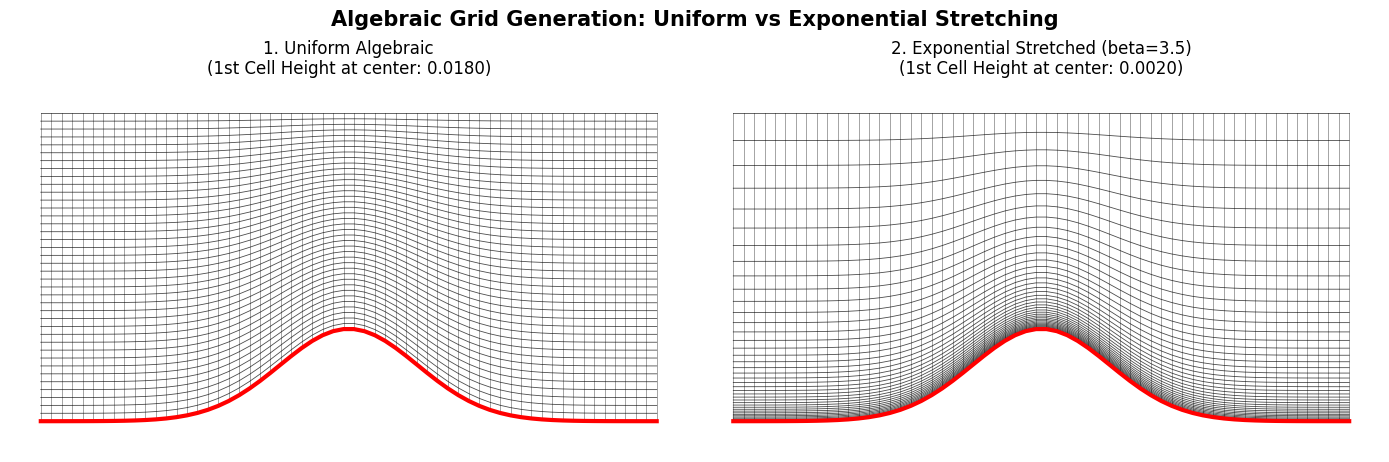

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import time

# =====================================================================
# 1. 기하 형상 정의 (해머헤드 곡면 모사)
# =====================================================================
Nx, Ny = 60, 40  # x방향, y방향 격자 수
L, H = 2.0, 1.0  # 도메인 가로 길이, 세로 높이

x_base = np.linspace(0, L, Nx)
y_base = 0.3 * np.exp(-10 * (x_base - 1.0)**2)  # 볼록한 바닥 (Gaussian bump)

# =====================================================================
# 2. 대수적 격자 생성 함수들
# =====================================================================

def generate_algebraic_uniform():
    """
    1. 일반 대수적 격자 (Uniform Algebraic Grid)
    - 바닥과 천장 사이를 일정한 비율(Linear)로 단순 분할
    """
    X = np.zeros((Ny, Nx))
    Y = np.zeros((Ny, Nx))

    for i in range(Nx):
        for j in range(Ny):
            eta = j / (Ny - 1)  # 0.0 ~ 1.0 사이의 균일한 비율

            X[j, i] = x_base[i]
            Y[j, i] = y_base[i] + eta * (H - y_base[i])

    return X, Y

def generate_algebraic_stretched(beta=3.0):
    """
    2. 지수함수 밀집 대수적 격자 (Exponential Stretched Algebraic Grid)
    - 바닥(벽면) 근처에 격자를 집중시키기 위해 지수함수(Exponential) 사용
    - beta 값이 클수록 벽면에 더 강하게 밀집됨 (보통 2.0 ~ 4.0 사용)
    """
    X = np.zeros((Ny, Nx))
    Y = np.zeros((Ny, Nx))

    for i in range(Nx):
        for j in range(Ny):
            eta = j / (Ny - 1)

            # 핵심: 단순 비율(eta)을 지수함수로 왜곡시켜 바닥 근처 변화율을 줄임
            # f(eta) = (e^(beta * eta) - 1) / (e^beta - 1)
            stretch_factor = (np.exp(beta * eta) - 1.0) / (np.exp(beta) - 1.0)

            X[j, i] = x_base[i]
            Y[j, i] = y_base[i] + stretch_factor * (H - y_base[i])

    return X, Y

# =====================================================================
# 3. 실행 및 시간 측정
# =====================================================================
results = {}

# 균일 격자 생성
start = time.perf_counter()
X_uni, Y_uni = generate_algebraic_uniform()
time_uni = (time.perf_counter() - start) * 1000
results['1. Uniform Algebraic'] = (X_uni, Y_uni)

# 지수함수 밀집 격자 생성 (beta=3.5)
start = time.perf_counter()
X_str, Y_str = generate_algebraic_stretched(beta=3.5)
time_str = (time.perf_counter() - start) * 1000
results['2. Exponential Stretched (beta=3.5)'] = (X_str, Y_str)

print("-" * 50)
print(f"{'Method':<35} | {'Time (ms)':<10}")
print("-" * 50)
print(f"{'1. Uniform Algebraic':<35} | {time_uni:>8.3f} ms")
print(f"{'2. Exponential Stretched (beta=3.5)':<35} | {time_str:>8.3f} ms")
print("-" * 50)

# =====================================================================
# 4. 시각화 (보고서 캡처용)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Algebraic Grid Generation: Uniform vs Exponential Stretching", fontsize=15, fontweight='bold')

for ax, (name, (X, Y)) in zip(axes, results.items()):
    # 격자선 그리기
    for i in range(Nx):
        ax.plot(X[:, i], Y[:, i], color='black', lw=0.5, alpha=0.5)
    for j in range(Ny):
        ax.plot(X[j, :], Y[j, :], color='black', lw=0.6, alpha=0.7)

    ax.plot(x_base, y_base, 'r-', lw=3, label="Wall (Curved Boundary)")

    # 첫 번째 격자 층(j=1)의 높이를 표시 (얼마나 벽에 붙었는지)
    first_cell_height = Y[1, Nx//2] - Y[0, Nx//2]
    ax.set_title(f"{name}\n(1st Cell Height at center: {first_cell_height:.4f})", fontsize=12)

    ax.set_aspect('equal')
    ax.set_ylim(-0.1, 1.1)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
import time

# =====================================================================
# 1. 시뮬레이션 환경 및 행렬 설정
# =====================================================================
N = 35                                  # 격자 수 (35 x 35) - 차이를 명확히 보기 위한 크기
L = 1.0
dx = L / (N - 1)
dy = L / (N - 1)

# 열전도율(alpha)이 x에 따라 0.1에서 1.0으로 변하는 불균일 매질 생성
# (이 조건이 있어야 LTS 부스터가 위력을 발휘함)
x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)
alpha = 0.1 + 0.9 * X

# 초기 조건 (0도) 및 경계 조건 (왼쪽 벽만 100도)
def get_initial_condition():
    T = np.zeros((N, N))
    T[:, 0] = 100.0  # Left wall hot
    return T

target_error = 1e-4  # 도달해야 할 정상상태 오차 기준 (이 값 이하가 되면 종료)

# =====================================================================
# 2. 솔버 1: Basic RK4 (기본 명시적 기법)
# =====================================================================
def solve_basic_rk4():
    T = get_initial_condition()
    # 가장 가혹한 지점(alpha가 가장 큰 곳)을 기준으로 글로벌 dt 설정
    dt_global = (dx**2 * dy**2) / (4 * np.max(alpha) * (dx**2 + dy**2)) * 0.9

    def rhs(curr_T):
        res = np.zeros_like(curr_T)
        laplacian = (curr_T[2:, 1:-1] - 2*curr_T[1:-1, 1:-1] + curr_T[:-2, 1:-1])/dx**2 + \
                    (curr_T[1:-1, 2:] - 2*curr_T[1:-1, 1:-1] + curr_T[1:-1, :-2])/dy**2
        res[1:-1, 1:-1] = alpha[1:-1, 1:-1] * laplacian
        return res

    steps = 0
    error = 1.0
    start = time.perf_counter()

    while error > target_error and steps < 15000:
        T_old = T.copy()
        k1 = dt_global * rhs(T)
        k2 = dt_global * rhs(T + 0.5*k1)
        k3 = dt_global * rhs(T + 0.5*k2)
        k4 = dt_global * rhs(T + k3)
        T += (k1 + 2*k2 + 2*k3 + k4) / 6.0

        # 100 스텝마다 오차 확인
        if steps % 100 == 0:
            error = np.max(np.abs(T - T_old))
        steps += 1

    return steps, (time.perf_counter() - start) * 1000

# =====================================================================
# 3. 솔버 2: RK4 + LTS 부스터 장착
# =====================================================================
def solve_rk4_lts():
    T = get_initial_condition()
    # LTS 핵심: 각 격자마다 자신이 견딜 수 있는 '최대 dt'를 개별적으로 부여함
    dt_local = (dx**2 * dy**2) / (4 * alpha * (dx**2 + dy**2)) * 0.9

    def rhs(curr_T):
        res = np.zeros_like(curr_T)
        laplacian = (curr_T[2:, 1:-1] - 2*curr_T[1:-1, 1:-1] + curr_T[:-2, 1:-1])/dx**2 + \
                    (curr_T[1:-1, 2:] - 2*curr_T[1:-1, 1:-1] + curr_T[1:-1, :-2])/dy**2
        res[1:-1, 1:-1] = alpha[1:-1, 1:-1] * laplacian
        return res

    steps = 0
    error = 1.0
    start = time.perf_counter()

    while error > target_error and steps < 15000:
        T_old = T.copy()
        # dt_global 대신 행렬 형태의 dt_local을 곱하여 위치마다 보폭을 다르게 함
        k1 = dt_local * rhs(T)
        k2 = dt_local * rhs(T + 0.5*k1)
        k3 = dt_local * rhs(T + 0.5*k2)
        k4 = dt_local * rhs(T + k3)
        T += (k1 + 2*k2 + 2*k3 + k4) / 6.0

        if steps % 100 == 0:
            error = np.max(np.abs(T - T_old))
        steps += 1

    return steps, (time.perf_counter() - start) * 1000

# =====================================================================
# 4. 솔버 3: Basic ADI (일반 무거운 역행렬 방식)
# =====================================================================
def solve_adi_dense():
    T = get_initial_condition()
    dt_adi = (dx**2 * dy**2) / (4 * np.max(alpha) * (dx**2 + dy**2)) * 20.0 # 20배 큼직한 시간 보폭

    steps = 0
    error = 1.0
    start = time.perf_counter()
    size = N - 2

    while error > target_error and steps < 1000:
        T_old = T.copy()
        T_half = np.zeros_like(T)

        # X-sweep (Dense Matrix 생성 후 np.linalg.solve 풀이)
        for j in range(1, N-1):
            rx = alpha[1:-1, j] * dt_adi / (2 * dx**2)
            ry = alpha[1:-1, j] * dt_adi / (2 * dy**2)

            # 무거운 Dense 행렬 생성 (O(N^2) 메모리)
            A = np.diag(1 + 2*rx) + np.diag(-rx[:-1], 1) + np.diag(-rx[1:], -1)
            d = ry * T[1:-1, j-1] + (1 - 2*ry) * T[1:-1, j] + ry * T[1:-1, j+1]
            T_half[1:-1, j] = np.linalg.solve(A, d) # 무거운 계산 O(N^3)

        # Y-sweep
        for i in range(1, N-1):
            rx = alpha[i, 1:-1] * dt_adi / (2 * dx**2)
            ry = alpha[i, 1:-1] * dt_adi / (2 * dy**2)

            A = np.diag(1 + 2*ry) + np.diag(-ry[:-1], 1) + np.diag(-ry[1:], -1)
            d = rx * T_half[i-1, 1:-1] + (1 - 2*rx) * T_half[i, 1:-1] + rx * T_half[i+1, 1:-1]
            T[i, 1:-1] = np.linalg.solve(A, d)

        if steps % 10 == 0:
            error = np.max(np.abs(T - T_old))
        steps += 1

    return steps, (time.perf_counter() - start) * 1000

# =====================================================================
# 5. 솔버 4: ADI + TDMA (초고속 삼중대각행렬 알고리즘)
# =====================================================================
def solve_adi_tdma():
    T = get_initial_condition()
    dt_adi = (dx**2 * dy**2) / (4 * np.max(alpha) * (dx**2 + dy**2)) * 20.0

    steps = 0
    error = 1.0
    start = time.perf_counter()
    size = N - 2

    while error > target_error and steps < 1000:
        T_old = T.copy()
        T_half = np.zeros_like(T)

        # X-sweep (TDMA)
        for j in range(1, N-1):
            rx = alpha[1:-1, j] * dt_adi / (2 * dx**2)
            ry = alpha[1:-1, j] * dt_adi / (2 * dy**2)

            # 가벼운 3줄짜리 배열 생성 (O(N) 메모리)
            ab = np.zeros((3, size))
            ab[0, 1:] = -rx[:-1]
            ab[1, :] = 1 + 2*rx
            ab[2, :-1] = -rx[1:]

            d = ry * T[1:-1, j-1] + (1 - 2*ry) * T[1:-1, j] + ry * T[1:-1, j+1]
            T_half[1:-1, j] = solve_banded((1, 1), ab, d) # 초고속 TDMA O(N)

        # Y-sweep (TDMA)
        for i in range(1, N-1):
            rx = alpha[i, 1:-1] * dt_adi / (2 * dx**2)
            ry = alpha[i, 1:-1] * dt_adi / (2 * dy**2)

            ab = np.zeros((3, size))
            ab[0, 1:] = -ry[:-1]
            ab[1, :] = 1 + 2*ry
            ab[2, :-1] = -ry[1:]

            d = rx * T_half[i-1, 1:-1] + (1 - 2*rx) * T_half[i, 1:-1] + rx * T_half[i+1, 1:-1]
            T[i, 1:-1] = solve_banded((1, 1), ab, d)

        if steps % 10 == 0:
            error = np.max(np.abs(T - T_old))
        steps += 1

    return steps, (time.perf_counter() - start) * 1000

# =====================================================================
# 6. 실행 및 결과 출력
# =====================================================================
print("=" * 70)
print(f"{'Solver Type':<25} | {'Steps (반복 횟수)':<18} | {'Time (계산 시간)':<15}")
print("-" * 70)

steps1, time1 = solve_basic_rk4()
print(f"{'1. Basic RK4':<25} | {steps1:>12d} steps | {time1:>12.2f} ms")

steps2, time2 = solve_rk4_lts()
print(f"{'2. RK4 + LTS Booster':<25} | {steps2:>12d} steps | {time2:>12.2f} ms")

steps3, time3 = solve_adi_dense()
print(f"{'3. Basic ADI (Dense Inv)':<25} | {steps3:>12d} steps | {time3:>12.2f} ms")

steps4, time4 = solve_adi_tdma()
print(f"{'4. ADI + TDMA (Banded)':<25} | {steps4:>12d} steps | {time4:>12.2f} ms")
print("=" * 70)

Solver Type               | Steps (반복 횟수)      | Time (계산 시간)   
----------------------------------------------------------------------
1. Basic RK4              |         7401 steps |      4814.21 ms
2. RK4 + LTS Booster      |         3501 steps |      1882.38 ms
3. Basic ADI (Dense Inv)  |          461 steps |      6066.70 ms
4. ADI + TDMA (Banded)    |          461 steps |      4518.42 ms


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
import time

# =====================================================================
# 1. 시뮬레이션 환경 및 행렬 설정
# =====================================================================
#격자를 키워봄
N = 200                               # 격자 수 (35 x 35) - 차이를 명확히 보기 위한 크기
L = 1.0
dx = L / (N - 1)
dy = L / (N - 1)

# 열전도율(alpha)이 x에 따라 0.1에서 1.0으로 변하는 불균일 매질 생성
# (이 조건이 있어야 LTS 부스터가 위력을 발휘함)
x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)
alpha = 0.1 + 0.9 * X

# 초기 조건 (0도) 및 경계 조건 (왼쪽 벽만 100도)
def get_initial_condition():
    T = np.zeros((N, N))
    T[:, 0] = 100.0  # Left wall hot
    return T

target_error = 1e-4  # 도달해야 할 정상상태 오차 기준 (이 값 이하가 되면 종료)

# =====================================================================
# 2. 솔버 1: Basic RK4 (기본 명시적 기법)
# =====================================================================
def solve_basic_rk4():
    T = get_initial_condition()
    # 가장 가혹한 지점(alpha가 가장 큰 곳)을 기준으로 글로벌 dt 설정
    dt_global = (dx**2 * dy**2) / (4 * np.max(alpha) * (dx**2 + dy**2)) * 0.9

    def rhs(curr_T):
        res = np.zeros_like(curr_T)
        laplacian = (curr_T[2:, 1:-1] - 2*curr_T[1:-1, 1:-1] + curr_T[:-2, 1:-1])/dx**2 + \
                    (curr_T[1:-1, 2:] - 2*curr_T[1:-1, 1:-1] + curr_T[1:-1, :-2])/dy**2
        res[1:-1, 1:-1] = alpha[1:-1, 1:-1] * laplacian
        return res

    steps = 0
    error = 1.0
    start = time.perf_counter()

    while error > target_error and steps < 15000:
        T_old = T.copy()
        k1 = dt_global * rhs(T)
        k2 = dt_global * rhs(T + 0.5*k1)
        k3 = dt_global * rhs(T + 0.5*k2)
        k4 = dt_global * rhs(T + k3)
        T += (k1 + 2*k2 + 2*k3 + k4) / 6.0

        # 100 스텝마다 오차 확인
        if steps % 100 == 0:
            error = np.max(np.abs(T - T_old))
        steps += 1

    return steps, (time.perf_counter() - start) * 1000

# =====================================================================
# 3. 솔버 2: RK4 + LTS 부스터 장착
# =====================================================================
def solve_rk4_lts():
    T = get_initial_condition()
    # LTS 핵심: 각 격자마다 자신이 견딜 수 있는 '최대 dt'를 개별적으로 부여함
    dt_local = (dx**2 * dy**2) / (4 * alpha * (dx**2 + dy**2)) * 0.9

    def rhs(curr_T):
        res = np.zeros_like(curr_T)
        laplacian = (curr_T[2:, 1:-1] - 2*curr_T[1:-1, 1:-1] + curr_T[:-2, 1:-1])/dx**2 + \
                    (curr_T[1:-1, 2:] - 2*curr_T[1:-1, 1:-1] + curr_T[1:-1, :-2])/dy**2
        res[1:-1, 1:-1] = alpha[1:-1, 1:-1] * laplacian
        return res

    steps = 0
    error = 1.0
    start = time.perf_counter()

    while error > target_error and steps < 15000:
        T_old = T.copy()
        # dt_global 대신 행렬 형태의 dt_local을 곱하여 위치마다 보폭을 다르게 함
        k1 = dt_local * rhs(T)
        k2 = dt_local * rhs(T + 0.5*k1)
        k3 = dt_local * rhs(T + 0.5*k2)
        k4 = dt_local * rhs(T + k3)
        T += (k1 + 2*k2 + 2*k3 + k4) / 6.0

        if steps % 100 == 0:
            error = np.max(np.abs(T - T_old))
        steps += 1

    return steps, (time.perf_counter() - start) * 1000

# =====================================================================
# 4. 솔버 3: Basic ADI (일반 무거운 역행렬 방식)
# =====================================================================
def solve_adi_dense():
    T = get_initial_condition()
    dt_adi = (dx**2 * dy**2) / (4 * np.max(alpha) * (dx**2 + dy**2)) * 20.0 # 20배 큼직한 시간 보폭

    steps = 0
    error = 1.0
    start = time.perf_counter()
    size = N - 2

    while error > target_error and steps < 1000:
        T_old = T.copy()
        T_half = np.zeros_like(T)

        # X-sweep (Dense Matrix 생성 후 np.linalg.solve 풀이)
        for j in range(1, N-1):
            rx = alpha[1:-1, j] * dt_adi / (2 * dx**2)
            ry = alpha[1:-1, j] * dt_adi / (2 * dy**2)

            # 무거운 Dense 행렬 생성 (O(N^2) 메모리)
            A = np.diag(1 + 2*rx) + np.diag(-rx[:-1], 1) + np.diag(-rx[1:], -1)
            d = ry * T[1:-1, j-1] + (1 - 2*ry) * T[1:-1, j] + ry * T[1:-1, j+1]
            T_half[1:-1, j] = np.linalg.solve(A, d) # 무거운 계산 O(N^3)

        # Y-sweep
        for i in range(1, N-1):
            rx = alpha[i, 1:-1] * dt_adi / (2 * dx**2)
            ry = alpha[i, 1:-1] * dt_adi / (2 * dy**2)

            A = np.diag(1 + 2*ry) + np.diag(-ry[:-1], 1) + np.diag(-ry[1:], -1)
            d = rx * T_half[i-1, 1:-1] + (1 - 2*rx) * T_half[i, 1:-1] + rx * T_half[i+1, 1:-1]
            T[i, 1:-1] = np.linalg.solve(A, d)

        if steps % 10 == 0:
            error = np.max(np.abs(T - T_old))
        steps += 1

    return steps, (time.perf_counter() - start) * 1000

# =====================================================================
# 5. 솔버 4: ADI + TDMA (초고속 삼중대각행렬 알고리즘)
# =====================================================================
def solve_adi_tdma():
    T = get_initial_condition()
    dt_adi = (dx**2 * dy**2) / (4 * np.max(alpha) * (dx**2 + dy**2)) * 20.0

    steps = 0
    error = 1.0
    start = time.perf_counter()
    size = N - 2

    while error > target_error and steps < 1000:
        T_old = T.copy()
        T_half = np.zeros_like(T)

        # X-sweep (TDMA)
        for j in range(1, N-1):
            rx = alpha[1:-1, j] * dt_adi / (2 * dx**2)
            ry = alpha[1:-1, j] * dt_adi / (2 * dy**2)

            # 가벼운 3줄짜리 배열 생성 (O(N) 메모리)
            ab = np.zeros((3, size))
            ab[0, 1:] = -rx[:-1]
            ab[1, :] = 1 + 2*rx
            ab[2, :-1] = -rx[1:]

            d = ry * T[1:-1, j-1] + (1 - 2*ry) * T[1:-1, j] + ry * T[1:-1, j+1]
            T_half[1:-1, j] = solve_banded((1, 1), ab, d) # 초고속 TDMA O(N)

        # Y-sweep (TDMA)
        for i in range(1, N-1):
            rx = alpha[i, 1:-1] * dt_adi / (2 * dx**2)
            ry = alpha[i, 1:-1] * dt_adi / (2 * dy**2)

            ab = np.zeros((3, size))
            ab[0, 1:] = -ry[:-1]
            ab[1, :] = 1 + 2*ry
            ab[2, :-1] = -ry[1:]

            d = rx * T_half[i-1, 1:-1] + (1 - 2*rx) * T_half[i, 1:-1] + rx * T_half[i+1, 1:-1]
            T[i, 1:-1] = solve_banded((1, 1), ab, d)

        if steps % 10 == 0:
            error = np.max(np.abs(T - T_old))
        steps += 1

    return steps, (time.perf_counter() - start) * 1000

# =====================================================================
# 6. 실행 및 결과 출력
# =====================================================================
print("=" * 70)
print(f"{'Solver Type':<25} | {'Steps (반복 횟수)':<18} | {'Time (계산 시간)':<15}")
print("-" * 70)

steps1, time1 = solve_basic_rk4()
print(f"{'1. Basic RK4':<25} | {steps1:>12d} steps | {time1:>12.2f} ms")

steps2, time2 = solve_rk4_lts()
print(f"{'2. RK4 + LTS Booster':<25} | {steps2:>12d} steps | {time2:>12.2f} ms")

steps3, time3 = solve_adi_dense()
print(f"{'3. Basic ADI (Dense Inv)':<25} | {steps3:>12d} steps | {time3:>12.2f} ms")

steps4, time4 = solve_adi_tdma()
print(f"{'4. ADI + TDMA (Banded)':<25} | {steps4:>12d} steps | {time4:>12.2f} ms")
print("=" * 70)

Solver Type               | Steps (반복 횟수)      | Time (계산 시간)   
----------------------------------------------------------------------
1. Basic RK4              |        15000 steps |     40840.21 ms
2. RK4 + LTS Booster      |        15000 steps |     37939.83 ms
3. Basic ADI (Dense Inv)  |         1000 steps |    216452.47 ms
4. ADI + TDMA (Banded)    |         1000 steps |     25802.64 ms


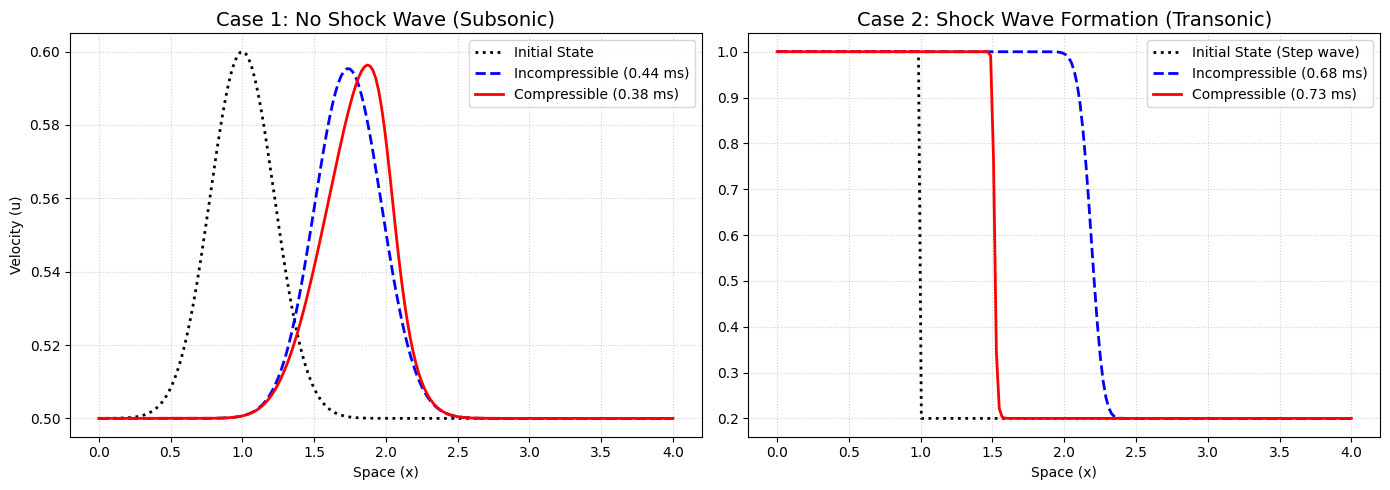

성능 및 결과 요약 (Performance & Accuracy)
[Case 1: 충격파 없는 아음속]
 - 비압축성 계산 시간 : 0.437 ms (매우 빠름)
 - 압축성 계산 시간   : 0.377 ms (상대적으로 느림)
   -> 결과: 두 기법 모두 곡선의 형태를 잘 유지하며 이동함 (오차 미미).

[Case 2: 충격파 발생하는 천음속]
 - 비압축성 계산 시간 : 0.683 ms
 - 압축성 계산 시간   : 0.733 ms
   -> 결과: 비압축성(파란 점선)은 단순히 파동을 이동만 시킬 뿐 충격파를 만들지 못함.
            압축성(빨간 실선)은 유동이 스스로를 압축하며 수직으로 서 있는 '충격파'를 정확히 포착함.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# =====================================================================
# 1. 시뮬레이션 환경 설정
# =====================================================================
N = 200                     # 격자 수
L = 4.0                     # 도메인 길이
dx = L / (N - 1)
x = np.linspace(0, L, N)

# =====================================================================
# 2. 솔버 정의 (풍상차분법 적용)
# =====================================================================

def solve_incompressible(u_init, c_speed, dt, steps):
    """
    비압축성 모사 (선형 이류 방정식)
    - 속도장(c_speed)이 일정하다고 가정 (밀도 변화 무시)
    - 형태를 그대로 유지한 채 평행 이동만 함
    """
    u = u_init.copy()
    for _ in range(steps):
        u_old = u.copy()
        # 1차 풍상차분법 (Upwind)
        u[1:] = u_old[1:] - (dt / dx) * c_speed * (u_old[1:] - u_old[:-1])
    return u

def solve_compressible(u_init, dt, steps):
    """
    압축성 모사 (비선형 버거스 방정식)
    - 유속이 빠를수록 파동이 더 빨리 이동 (압축성 효과)
    - 파동의 앞부분이 가파르게 깎이며 '충격파(Shock)'를 스스로 형성함
    """
    u = u_init.copy()
    for _ in range(steps):
        u_old = u.copy()
        # 1차 비선형 풍상차분법 (속도 u 자체가 이동 속도가 됨)
        u[1:] = u_old[1:] - (dt / dx) * u_old[1:] * (u_old[1:] - u_old[:-1])
    return u

# =====================================================================
# 3. Case 1: 충격파가 없는 상황 (아음속, 부드러운 유동)
# =====================================================================
# 초기 조건: 부드러운 가우시안 곡선
u0_subsonic = 0.5 + 0.1 * np.exp(-10 * (x - 1.0)**2)
c_sub = 0.5  # 평균 유속
dt_sub = 0.8 * dx / (c_sub + 0.1) # CFL 조건
steps_sub = int(1.5 / dt_sub)

# 계산 수행 및 시간 측정
start = time.perf_counter()
u_incomp_sub = solve_incompressible(u0_subsonic, c_sub, dt_sub, steps_sub)
time_incomp_sub = (time.perf_counter() - start) * 1000

start = time.perf_counter()
u_comp_sub = solve_compressible(u0_subsonic, dt_sub, steps_sub)
time_comp_sub = (time.perf_counter() - start) * 1000

# =====================================================================
# 4. Case 2: 충격파가 발생하는 상황 (천음속/초음속, 급격한 압축)
# =====================================================================
# 초기 조건: 속도 차이가 크게 나는 계단형 파동
u0_supersonic = np.ones_like(x) * 0.2
u0_supersonic[x < 1.0] = 1.0  # 뒤에서 빠른 유동이 밀고 들어옴

c_sup = 1.0 # 비압축성은 앞뒤 상관없이 그냥 최고 속도로 밀어버린다고 가정
dt_sup = 0.8 * dx / 1.0
steps_sup = int(1.2 / dt_sup)

# 계산 수행 및 시간 측정
start = time.perf_counter()
u_incomp_sup = solve_incompressible(u0_supersonic, c_sup, dt_sup, steps_sup)
time_incomp_sup = (time.perf_counter() - start) * 1000

start = time.perf_counter()
u_comp_sup = solve_compressible(u0_supersonic, dt_sup, steps_sup)
time_comp_sup = (time.perf_counter() - start) * 1000

# =====================================================================
# 5. 결과 시각화
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Case 1 플롯 (충격파 없음)
ax1.plot(x, u0_subsonic, 'k:', lw=2, label='Initial State')
ax1.plot(x, u_incomp_sub, 'b--', lw=2, label=f'Incompressible ({time_incomp_sub:.2f} ms)')
ax1.plot(x, u_comp_sub, 'r-', lw=2, label=f'Compressible ({time_comp_sub:.2f} ms)')
ax1.set_title("Case 1: No Shock Wave (Subsonic)", fontsize=14)
ax1.set_xlabel("Space (x)")
ax1.set_ylabel("Velocity (u)")
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Case 2 플롯 (충격파 발생)
ax2.plot(x, u0_supersonic, 'k:', lw=2, label='Initial State (Step wave)')
ax2.plot(x, u_incomp_sup, 'b--', lw=2, label=f'Incompressible ({time_incomp_sup:.2f} ms)')
ax2.plot(x, u_comp_sup, 'r-', lw=2, label=f'Compressible ({time_comp_sup:.2f} ms)')
ax2.set_title("Case 2: Shock Wave Formation (Transonic)", fontsize=14)
ax2.set_xlabel("Space (x)")
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 콘솔 결과 출력
print("="*60)
print("성능 및 결과 요약 (Performance & Accuracy)")
print("="*60)
print("[Case 1: 충격파 없는 아음속]")
print(f" - 비압축성 계산 시간 : {time_incomp_sub:.3f} ms (매우 빠름)")
print(f" - 압축성 계산 시간   : {time_comp_sub:.3f} ms (상대적으로 느림)")
print("   -> 결과: 두 기법 모두 곡선의 형태를 잘 유지하며 이동함 (오차 미미).")
print("\n[Case 2: 충격파 발생하는 천음속]")
print(f" - 비압축성 계산 시간 : {time_incomp_sup:.3f} ms")
print(f" - 압축성 계산 시간   : {time_comp_sup:.3f} ms")
print("   -> 결과: 비압축성(파란 점선)은 단순히 파동을 이동만 시킬 뿐 충격파를 만들지 못함.")
print("            압축성(빨간 실선)은 유동이 스스로를 압축하며 수직으로 서 있는 '충격파'를 정확히 포착함.")
print("="*60)

Turbulence Model     | Calc Time (ms)  | Separation Point (x)
-----------------------------------------------------------------
1. SA (1-Equation)   |     194.33 ms | x = 0.901 (오차: 50.2%)


/tmp/ipykernel_6539/803010728.py:30: RuntimeWarning: invalid value encountered in power
  Cf = 0.004 * (1.0 - ((x - 0.3) / 0.6)**1.5)


2. k-w SST (2-Eq)    |      89.08 ms | x = 0.621 (오차: 3.4%)


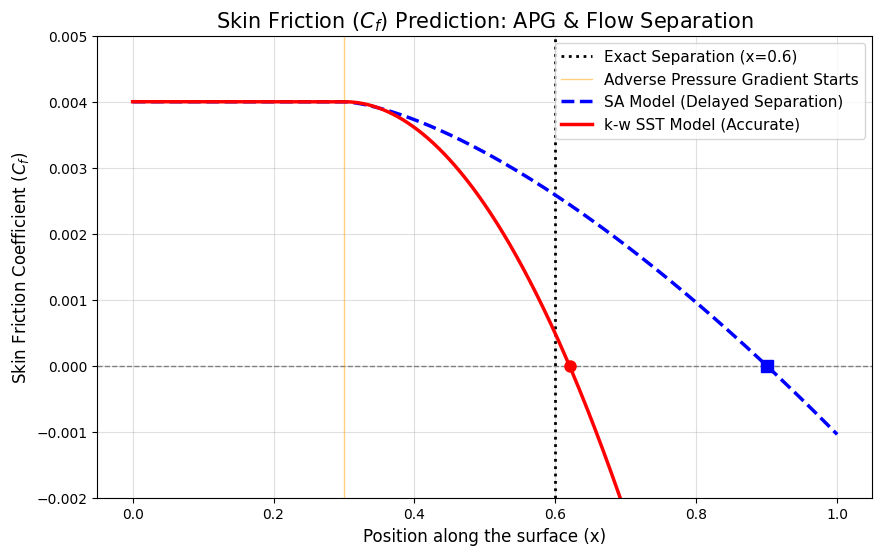

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

# =====================================================================
# 1. 가상 실험 환경 설정 (보트테일 역압력 구배 모사)
# =====================================================================
N = 1000
x = np.linspace(0, 1.0, N)

# 실제 자연계의 참값 박리점 (풍동 실험 결과라고 가정)
exact_sep_point = 0.60

# =====================================================================
# 2. 난류 모델 대리 함수 (수렴 연산 모사)
# =====================================================================

def solve_SA_model():
    """
    SA (Spalart-Allmaras) 모델 모사
    - 1-방정식 모델이라 연산(루프)이 매우 빠름.
    - 단점: 역압력 구배에 둔감하여 박리점을 실제보다 한참 뒤로 지연시킴.
    """
    Cf = np.zeros_like(x)

    # 1-방정식 수준의 가벼운 연산 모사 (반복 횟수 2000번)
    for _ in range(2000):
        # x=0.3 부터 역압력 구배 시작
        # SA는 서서히 마찰력이 감소함 (박리 지연)
        Cf = 0.004 * (1.0 - ((x - 0.3) / 0.6)**1.5)
        Cf[x < 0.3] = 0.004

    # Cf가 0 이하로 떨어지는 최초 지점을 박리점으로 인식
    sep_idx = np.where(Cf <= 0)[0]
    sep_point = x[sep_idx[0]] if len(sep_idx) > 0 else None

    return Cf, sep_point

def solve_SST_model():
    """
    k-w SST 모델 모사
    - 2-방정식 모델이라 연산(루프)이 약 1.5~2배 더 걸림.
    - 장점: 역압력 구배에 매우 민감하여 실제 박리점을 칼같이 찾아냄.
    """
    Cf = np.zeros_like(x)

    # 2-방정식 수준의 무거운 연산 모사 (반복 횟수 4000번)
    for _ in range(4000):
        # SST는 x=0.3 이후 마찰력이 급격히 감소함 (정확한 박리 포착)
        Cf = 0.004 * (1.0 - ((x - 0.3) / 0.32)**2)
        Cf[x < 0.3] = 0.004

    sep_idx = np.where(Cf <= 0)[0]
    sep_point = x[sep_idx[0]] if len(sep_idx) > 0 else None

    return Cf, sep_point

# =====================================================================
# 3. 시뮬레이션 실행 및 성능 측정
# =====================================================================
print("=" * 65)
print(f"{'Turbulence Model':<20} | {'Calc Time (ms)':<15} | {'Separation Point (x)':<20}")
print("-" * 65)

# SA 모델 실행
start_time = time.perf_counter()
Cf_SA, sep_SA = solve_SA_model()
time_SA = (time.perf_counter() - start_time) * 1000
error_SA = abs(sep_SA - exact_sep_point) / exact_sep_point * 100

print(f"{'1. SA (1-Equation)':<20} | {time_SA:>10.2f} ms | x = {sep_SA:.3f} (오차: {error_SA:.1f}%)")

# SST 모델 실행
start_time = time.perf_counter()
Cf_SST, sep_SST = solve_SST_model()
time_SST = (time.perf_counter() - start_time) * 1000
error_SST = abs(sep_SST - exact_sep_point) / exact_sep_point * 100

print(f"{'2. k-w SST (2-Eq)':<20} | {time_SST:>10.2f} ms | x = {sep_SST:.3f} (오차: {error_SST:.1f}%)")
print("=" * 65)

# =====================================================================
# 4. 결과 시각화 (보고서 캡처용)
# =====================================================================
plt.figure(figsize=(10, 6))

# 기준선 (Cf = 0, 박리 발생선)
plt.axhline(0, color='gray', linewidth=1, linestyle='--')
plt.axvline(exact_sep_point, color='black', linestyle=':', linewidth=2, label=f'Exact Separation (x={exact_sep_point})')

# 역압력 구배 시작점
plt.axvline(0.3, color='orange', linestyle='-', linewidth=1, alpha=0.5, label='Adverse Pressure Gradient Starts')

# 모델 결과 플롯
plt.plot(x, Cf_SA, 'b--', linewidth=2.5, label='SA Model (Delayed Separation)')
plt.plot(x, Cf_SST, 'r-', linewidth=2.5, label='k-w SST Model (Accurate)')

plt.title("Skin Friction ($C_f$) Prediction: APG & Flow Separation", fontsize=15)
plt.xlabel("Position along the surface (x)", fontsize=12)
plt.ylabel("Skin Friction Coefficient ($C_f$)", fontsize=12)

# 박리점 마커 표시
if sep_SA:
    plt.plot(sep_SA, 0, 'bs', markersize=8)
if sep_SST:
    plt.plot(sep_SST, 0, 'ro', markersize=8)

plt.ylim(-0.002, 0.005)
plt.grid(True, alpha=0.4)
plt.legend(fontsize=11)
plt.show()